In [1]:
# %% Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

from comms_lib.pluto import Pluto

In [2]:
!iio_info -s

Available contexts:
	0: 0456:b673 (Analog Devices Inc. PlutoSDR (ADALM-PLUTO)), serial=104473ae73930001150020009d682dc051 [usb:2.6.5]


Unable to create Local IIO context : Function not implemented (40)


In [3]:
sdr = Pluto("usb:2.6.5")

[1.       +0.j         0.9980267+0.06279052j 0.9921147+0.12533323j ...
 0.9822872-0.18738131j 0.9921147-0.12533323j 0.9980267-0.06279052j]


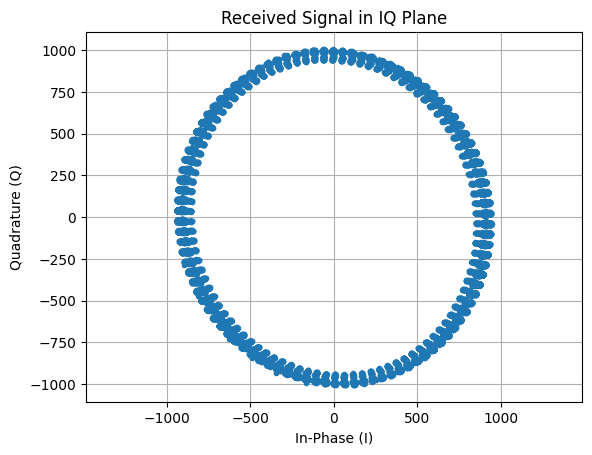

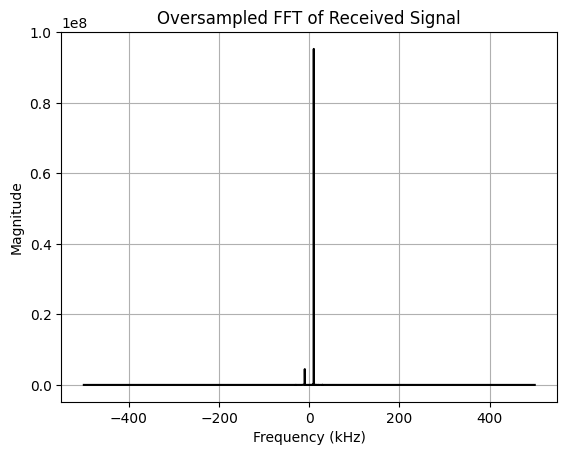

In [4]:
# %% Initialize Pluto SDR
sample_rate = 1e6  # baseband sampling rate (samples per second)
sdr.carrier_frequency = 815e6  # Set carrier frequency for transmission and reception
sdr.sample_rate = int(sample_rate)  # Set baseband sampling rate of Pluto

# %% Generate a signal to transmit
N = 10000  # number of samples to transmit
t = np.arange(N) / sample_rate  # time vector

# TODO: generate a complex signal at 10kHz. Hint: use `np.exp`
tx_signal = np.exp(2j * np.pi * 10e3 * t).astype(np.complex64)  # Change this line
print(tx_signal)
# %% Transmit and receive signal
# sdr.tx_gain = 0
sdr.tx(tx_signal)

rx_signal = sdr.rx()  # Capture raw samples from Pluto

# plot the received signal
plt.figure()
plt.plot(np.real(rx_signal), np.imag(rx_signal), ".")
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title("Received Signal in IQ Plane")
plt.grid(True)
plt.axis("equal")
plt.show()

# TODO: plot the fft of the received signal
rx_fft = np.fft.fftshift(np.abs(np.fft.fft(rx_signal)))  # Change this line!!

# Get the actual frequency of the FFT: from -sample_rate/2 to sample_rate/2
f = np.linspace(sample_rate / -2, sample_rate / 2, len(rx_fft))

plt.figure()
plt.plot(f / 1e3, rx_fft, color="black")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude")
plt.title("Oversampled FFT of Received Signal")
plt.grid(True)
plt.show()

### Antenna Resonance Frequency

As mentioned in the lecture, the resonance frequency of an antenna is determined by its physical dimensions. In the next section, we will empirically determine the resonance frequency of a dipole antenna by checking the received signal strength at various frequencies.

- At each frequency, you can transmit the same test signal you used in the previous section.
- Measure the received signal strength at each frequency. Hint: use `np.abs()` to get the absolute value of the received signal strength.
- Plot the received signal strength against frequency to visualize the resonance frequency. What's the resonance frequency of the dipole antenna?

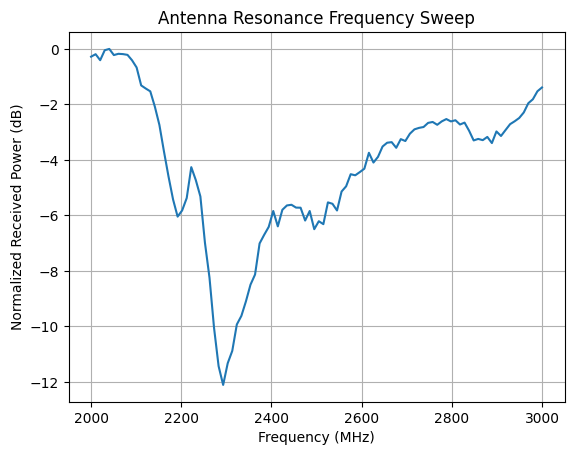

In [6]:
# %% Find the antenna resonance frequency by transmitting the same signal across dif
# ferent frequencies
frequencies = np.linspace(2000e6, 3000e6, 100)
rx_powers = []

for f in frequencies:
    sdr.carrier_frequency = int(f)
    sdr.tx(tx_signal)
    rx_signal = sdr.rx()
    
    power = np.mean(np.abs(rx_signal)**2)
    rx_powers.append(power)

rx_powers = np.array(rx_powers) / np.max(rx_powers)  # Normalize the received powers
rx_powers_db = 10 * np.log10(rx_powers)  # Convert to dB scale

# TODO: plot the received powers against frequencies
plt.figure()
plt.plot(frequencies / 1e6, rx_powers_db)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Normalized Received Power (dB)")
plt.title("Antenna Resonance Frequency Sweep")
plt.grid(True)
plt.show()